In [1]:
from local_utilities.dataset import get_dataset_sbert_train

X, y = get_dataset_sbert_train()

[nltk_data] Downloading package punkt_tab to /home/tobias/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
/home/tobias/.pyenv/versions/genai/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
X.shape

torch.Size([956714, 384])

In [3]:
y.shape

torch.Size([956714])

In [4]:
X[0].shape

torch.Size([384])

In [5]:
len(X) / 10

95671.4

In [6]:
HUMAN_LABEL = "Human written sentence"
AI_LABEL = "Generative AI fabricated sentence"
HUMAN_LABELF = "Human written sentence feature"
AI_LABELF = "Generative AI fabricated sentence feature"

ALPHA = 0.25
NUMBER = 25
SIZE=3

In [7]:
import math

def sigmoid(x):
    return (1 / (1 + math.exp(-x)))

In [8]:
"""
import torch

raw_data = []

# Extract data points for individual features
for i in range(NUMBER):
    index = torch.randint(0, X.size(0), (1,)).item()
    test = X[index]
    
    for j in range(len(test)):
        if len(raw_data) <= j:
            raw_data.append([[],[]]) # List elements for human, ai
            
        # Append current data point to raw data
        raw_data[j][y[index]].append(test[j])
"""

'\nimport torch\n\nraw_data = []\n\n# Extract data points for individual features\nfor i in range(NUMBER):\n    index = torch.randint(0, X.size(0), (1,)).item()\n    test = X[index]\n\n    for j in range(len(test)):\n        if len(raw_data) <= j:\n            raw_data.append([[],[]]) # List elements for human, ai\n\n        # Append current data point to raw data\n        raw_data[j][y[index]].append(test[j])\n'

In [9]:
"""
class MeanDiffs:
    def __init__(self, mean, human, ai):
        self.mean = mean
        self.human = human
        self.ai = ai
        
    def __repr__(self):
        return repr((self.mean, self.human, self.ai))
    
    def get_mean(self):
        return self.mean
    
    def get_human_points(self):
        return self.human
    
    def get_ai_points(self):
        return self.ai    
"""

'\nclass MeanDiffs:\n    def __init__(self, mean, human, ai):\n        self.mean = mean\n        self.human = human\n        self.ai = ai\n\n    def __repr__(self):\n        return repr((self.mean, self.human, self.ai))\n\n    def get_mean(self):\n        return self.mean\n\n    def get_human_points(self):\n        return self.human\n\n    def get_ai_points(self):\n        return self.ai    \n'

In [10]:
"""
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

fig = plt.figure(figsize=(15,5))
ax = fig.add_subplot()

# Iterate over features
mean_diffs = []

ai_scattered = False
human_scattered = False
        
for i in tqdm(range(len(raw_data))):
    # Get human and AI data points
    human = np.abs(np.asarray(raw_data[i][0]))
    ai = np.abs(np.asarray(raw_data[i][1]))
    
    # Compute mean value
    mean = np.mean(np.append(human, ai))
    
    mean_h = np.mean(human)
    mean_ai = np.mean(ai)
    
    mean_diffs.append(MeanDiffs(np.abs(mean_h - mean_ai), human, ai))
    
    # Remove mean
    human -= mean
    ai -= mean
    
    # Show
    for j in human:
        if not human_scattered:
            human_scattered = True
            ax.scatter(i, sigmoid(j),  marker="o", alpha=ALPHA, c="g", s=SIZE, label=HUMAN_LABELF)
        else:
            ax.scatter(i, sigmoid(j),  marker="o", alpha=ALPHA, c="g", s=SIZE)
    
    for j in ai:
        if not ai_scattered:
            ai_scattered = True
            ax.scatter(i, sigmoid(j), marker="o", alpha=ALPHA, c="r", s=SIZE, label=AI_LABELF)
        else:
            ax.scatter(i, sigmoid(j), marker="o", alpha=ALPHA, c="r", s=SIZE)
    
# draw
plt.xlabel("Feature")
plt.ylabel("Value of feature")
ax.legend()
plt.title("Sentence visualization: all features (scaled; 25 samples)")
plt.show()
"""

'\nimport matplotlib.pyplot as plt\nimport numpy as np\nfrom tqdm import tqdm\n\nfig = plt.figure(figsize=(15,5))\nax = fig.add_subplot()\n\n# Iterate over features\nmean_diffs = []\n\nai_scattered = False\nhuman_scattered = False\n\nfor i in tqdm(range(len(raw_data))):\n    # Get human and AI data points\n    human = np.abs(np.asarray(raw_data[i][0]))\n    ai = np.abs(np.asarray(raw_data[i][1]))\n\n    # Compute mean value\n    mean = np.mean(np.append(human, ai))\n\n    mean_h = np.mean(human)\n    mean_ai = np.mean(ai)\n\n    mean_diffs.append(MeanDiffs(np.abs(mean_h - mean_ai), human, ai))\n\n    # Remove mean\n    human -= mean\n    ai -= mean\n\n    # Show\n    for j in human:\n        if not human_scattered:\n            human_scattered = True\n            ax.scatter(i, sigmoid(j),  marker="o", alpha=ALPHA, c="g", s=SIZE, label=HUMAN_LABELF)\n        else:\n            ax.scatter(i, sigmoid(j),  marker="o", alpha=ALPHA, c="g", s=SIZE)\n\n    for j in ai:\n        if not ai_scatt

In [11]:
"""
# Get most important features
diffs = sorted(mean_diffs, key=lambda mean: mean.mean, reverse=True)
important_features = diffs[:20]
"""

'\n# Get most important features\ndiffs = sorted(mean_diffs, key=lambda mean: mean.mean, reverse=True)\nimportant_features = diffs[:20]\n'

In [12]:
"""
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot()

ai_scattered = False
human_scattered = False

for i in range(len(important_features)):
    human = important_features[i].get_human_points()
    ai = important_features[i].get_ai_points()
    mean = important_features[i].get_mean()
    
    # Remove mean
    human -= mean
    ai -= mean
    
    # Show
    for j in human:
        if not human_scattered:
            human_scattered = True
            ax.scatter(i, sigmoid(j)**0.5,  marker="o", alpha=ALPHA, c="g", label=HUMAN_LABELF)
        else:
            ax.scatter(i, sigmoid(j)**0.5,  marker="o", alpha=ALPHA, c="g")
        
    for j in ai:
        if not ai_scattered:
            ai_scattered = True
            ax.scatter(i, sigmoid(j)**0.5, marker="o", alpha=ALPHA, c="r", label=AI_LABELF)
        else:
            ax.scatter(i, sigmoid(j)**0.5, marker="o", alpha=ALPHA, c="r")
    
# draw
plt.xlabel("Feature")
plt.ylabel("Value of feature")
plt.legend()
plt.title("Sentence visualization: main features (scaled; 25 samples)")
plt.show()
"""

'\nfig = plt.figure(figsize=(10,5))\nax = fig.add_subplot()\n\nai_scattered = False\nhuman_scattered = False\n\nfor i in range(len(important_features)):\n    human = important_features[i].get_human_points()\n    ai = important_features[i].get_ai_points()\n    mean = important_features[i].get_mean()\n\n    # Remove mean\n    human -= mean\n    ai -= mean\n\n    # Show\n    for j in human:\n        if not human_scattered:\n            human_scattered = True\n            ax.scatter(i, sigmoid(j)**0.5,  marker="o", alpha=ALPHA, c="g", label=HUMAN_LABELF)\n        else:\n            ax.scatter(i, sigmoid(j)**0.5,  marker="o", alpha=ALPHA, c="g")\n\n    for j in ai:\n        if not ai_scattered:\n            ai_scattered = True\n            ax.scatter(i, sigmoid(j)**0.5, marker="o", alpha=ALPHA, c="r", label=AI_LABELF)\n        else:\n            ax.scatter(i, sigmoid(j)**0.5, marker="o", alpha=ALPHA, c="r")\n\n# draw\nplt.xlabel("Feature")\nplt.ylabel("Value of feature")\nplt.legend()\nplt.

In [13]:
def normalize(data):
    return (data - np.min(data)) / (np.max(data) - np.min(data))

In [14]:
"""
plt.figure(figsize=(5,10))

ai_scattered = False
human_scattered = False

for i in range(len(important_features)):
    human = important_features[i].get_human_points()
    ai = important_features[i].get_ai_points()
    mean = important_features[i].get_mean()
    
    # Remove mean
    human -= mean
    ai -= mean
    
    human = normalize(human)
    ai = normalize(ai)
    
    # Show
    for j in human:
        if not human_scattered:
            human_scattered = True
            plt.scatter(i, j,  marker="o", alpha=ALPHA, c="g", label=HUMAN_LABELF)
        else:
            plt.scatter(i, j,  marker="o", alpha=ALPHA, c="g")
        
    
    for j in ai:
        if not ai_scattered:
            ai_scattered = True
            plt.scatter(i, j, marker="o", alpha=ALPHA, c="r", label=AI_LABELF)
        else:
            plt.scatter(i, j, marker="o", alpha=ALPHA, c="r")
        

# draw
plt.xlabel("Feature")
plt.ylabel("Value of feature")
plt.legend()
plt.title("Sentence visualization: main features (normalized; 25 samples)")
plt.show()
"""

'\nplt.figure(figsize=(5,10))\n\nai_scattered = False\nhuman_scattered = False\n\nfor i in range(len(important_features)):\n    human = important_features[i].get_human_points()\n    ai = important_features[i].get_ai_points()\n    mean = important_features[i].get_mean()\n\n    # Remove mean\n    human -= mean\n    ai -= mean\n\n    human = normalize(human)\n    ai = normalize(ai)\n\n    # Show\n    for j in human:\n        if not human_scattered:\n            human_scattered = True\n            plt.scatter(i, j,  marker="o", alpha=ALPHA, c="g", label=HUMAN_LABELF)\n        else:\n            plt.scatter(i, j,  marker="o", alpha=ALPHA, c="g")\n\n\n    for j in ai:\n        if not ai_scattered:\n            ai_scattered = True\n            plt.scatter(i, j, marker="o", alpha=ALPHA, c="r", label=AI_LABELF)\n        else:\n            plt.scatter(i, j, marker="o", alpha=ALPHA, c="r")\n\n\n# draw\nplt.xlabel("Feature")\nplt.ylabel("Value of feature")\nplt.legend()\nplt.title("Sentence visual

In [15]:
import torch
from tqdm import tqdm
ai_data = []
h_data = []

raw_data_full = []

SAMPLES = 100000

for i in tqdm(range(SAMPLES)):
    index = torch.randint(0, X.size(0), (1,)).item()
    raw_data_full.append([X[index], y[index]])

for x in raw_data_full:
    if x[1] == 1:
        ai_data.append(x[0])
    else:
        h_data.append(x[0])

100%|██████████| 100000/100000 [00:00<00:00, 150879.83it/s]


In [16]:
# Principal Component Analysis to shape 384-sized arrays down to 3 dimensions

from sklearn.decomposition import PCA
pca = PCA(n_components=3)
h_reduced3d = pca.fit_transform(h_data)
ai_reduced3d = pca.fit_transform(ai_data)

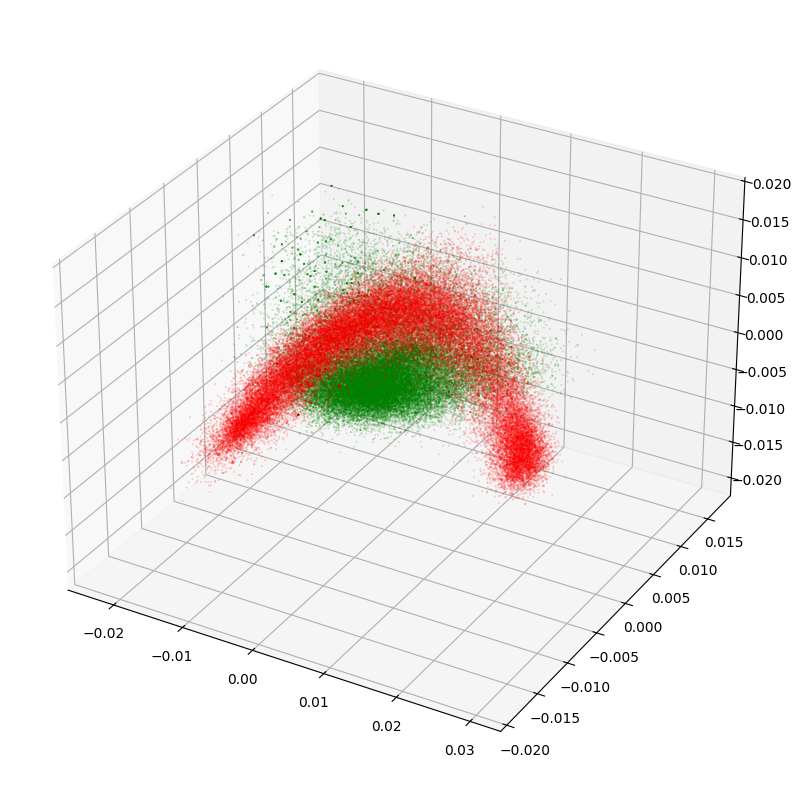

In [17]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection="3d")

ax.scatter(h_reduced3d[:,0], h_reduced3d[:,1], h_reduced3d[:,2], c="g", label=HUMAN_LABEL, s=.125, alpha=.25)
ax.scatter(ai_reduced3d[:,0], ai_reduced3d[:,1], ai_reduced3d[:,2], c="r", label=AI_LABEL, s=.125, alpha=.25)

#ax.legend()
#plt.title(f"Sentence visualization: principal component analysis ({SAMPLES} samples)")
plt.savefig(f"./data/figures/pca.pdf")
plt.show()

In [18]:
"""
pca = PCA(n_components=2)
h_reduced = pca.fit_transform(h_data)
ai_reduced = pca.fit_transform(ai_data)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot()

ax.scatter(h_reduced[:,0], h_reduced[:,1], c="g", label=HUMAN_LABEL)
ax.scatter(ai_reduced[:,0], ai_reduced[:,1], c="r", label=AI_LABEL)
ax.legend()

plt.title(f"Sentence visualization: principal component analysis ({SAMPLES} samples)")
plt.show()
"""

'\npca = PCA(n_components=2)\nh_reduced = pca.fit_transform(h_data)\nai_reduced = pca.fit_transform(ai_data)\n\nfig = plt.figure(figsize=(10, 10))\nax = fig.add_subplot()\n\nax.scatter(h_reduced[:,0], h_reduced[:,1], c="g", label=HUMAN_LABEL)\nax.scatter(ai_reduced[:,0], ai_reduced[:,1], c="r", label=AI_LABEL)\nax.legend()\n\nplt.title(f"Sentence visualization: principal component analysis ({SAMPLES} samples)")\nplt.show()\n'